In [146]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.preprocessing import StandardScaler

print("All good!")

All good!


In [147]:
import nflreadpy as nfl

## Phase 1: Loading data & scaling down to key columns

In [148]:
#Load seasons play-by-play data
pbp = nfl.load_pbp([2021, 2022, 2023, 2024, 2025])

#Load player game-level stats for multiple seasons
player_stats = nfl.load_player_stats([2021, 2022, 2023, 2024, 2025])

#Load all available team level stats
team_stats = nfl.load_team_stats(seasons=True)

#convert from Polars to pandas
pbp = pbp.to_pandas()

In [149]:
print(pbp.shape)
print(pbp.columns.tolist())
pbp.head()

(247284, 372)
['play_id', 'game_id', 'old_game_id', 'home_team', 'away_team', 'season_type', 'week', 'posteam', 'posteam_type', 'defteam', 'side_of_field', 'yardline_100', 'game_date', 'quarter_seconds_remaining', 'half_seconds_remaining', 'game_seconds_remaining', 'game_half', 'quarter_end', 'drive', 'sp', 'qtr', 'down', 'goal_to_go', 'time', 'yrdln', 'ydstogo', 'ydsnet', 'desc', 'play_type', 'yards_gained', 'shotgun', 'no_huddle', 'qb_dropback', 'qb_kneel', 'qb_spike', 'qb_scramble', 'pass_length', 'pass_location', 'air_yards', 'yards_after_catch', 'run_location', 'run_gap', 'field_goal_result', 'kick_distance', 'extra_point_result', 'two_point_conv_result', 'home_timeouts_remaining', 'away_timeouts_remaining', 'timeout', 'timeout_team', 'td_team', 'td_player_name', 'td_player_id', 'posteam_timeouts_remaining', 'defteam_timeouts_remaining', 'total_home_score', 'total_away_score', 'posteam_score', 'defteam_score', 'score_differential', 'posteam_score_post', 'defteam_score_post', 'scor

,play_id,game_id,old_game_id,home_team,away_team,season_type,week,posteam,posteam_type,defteam,side_of_field,yardline_100,game_date,quarter_seconds_remaining,half_seconds_remaining,game_seconds_remaining,game_half,quarter_end,drive,sp,qtr,down,goal_to_go,time,yrdln,ydstogo,ydsnet,desc,play_type,yards_gained,shotgun,no_huddle,qb_dropback,qb_kneel,qb_spike,qb_scramble,pass_length,pass_location,air_yards,yards_after_catch,...,surface,temp,wind,home_coach,away_coach,stadium_id,game_stadium,aborted_play,success,passer,passer_jersey_number,rusher,rusher_jersey_number,receiver,receiver_jersey_number,pass,rush,first_down,special,play,passer_id,rusher_id,receiver_id,name,jersey_number,id,fantasy_player_name,fantasy_player_id,fantasy,fantasy_id,out_of_bounds,home_opening_kickoff,qb_epa,xyac_epa,xyac_mean_yardage,xyac_median_yardage,xyac_success,xyac_fd,xpass,pass_oe
0,1.0,2021_01_ARI_TEN,2021091207,TEN,ARI,REG,1,NaN,NaN,NaN,NaN,NaN,2021-09-12,900.0,1800.0,3600.0,Half1,0.0,NaN,0.0,1.0,NaN,0,15:00,ARI 35,0.0,NaN,GAME,NaN,NaN,0.0,0.0,NaN,0.0,0.0,0.0,NaN,NaN,NaN,NaN,...,grass,82.0,8.0,Mike Vrabel,Kliff Kingsbury,NAS00,Nissan Stadium,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,40.0,2021_01_ARI_TEN,2021091207,TEN,ARI,REG,1,TEN,home,ARI,ARI,35.0,2021-09-12,900.0,1800.0,3600.0,Half1,0.0,1.0,0.0,1.0,NaN,0,15:00,ARI 35,0.0,0.0,5-M.Prater kicks 65 yards from ARI 35 to end z...,kickoff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,...,grass,82.0,8.0,Mike Vrabel,Kliff Kingsbury,NAS00,Nissan Stadium,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,55.0,2021_01_ARI_TEN,2021091207,TEN,ARI,REG,1,TEN,home,ARI,TEN,75.0,2021-09-12,900.0,1800.0,3600.0,Half1,0.0,1.0,0.0,1.0,1.0,0,15:00,TEN 25,10.0,0.0,(15:00) 22-D.Henry left tackle to TEN 22 for -...,run,-3.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,...,grass,82.0,8.0,Mike Vrabel,Kliff Kingsbury,NAS00,Nissan Stadium,0.0,0.0,NaN,NaN,D.Henry,22.0,NaN,NaN,0.0,1.0,0.0,0.0,1.0,NaN,00-0032764,NaN,D.Henry,22.0,00-0032764,D.Henry,00-0032764,D.Henry,00-0032764,0.0,1.0,-1.399805,NaN,NaN,NaN,NaN,NaN,0.491433,-49.143299
3,76.0,2021_01_ARI_TEN,2021091207,TEN,ARI,REG,1,TEN,home,ARI,TEN,78.0,2021-09-12,863.0,1763.0,3563.0,Half1,0.0,1.0,0.0,1.0,2.0,0,14:23,TEN 22,13.0,0.0,(14:23) (Shotgun) 17-R.Tannehill pass short mi...,pass,3.0,1.0,0.0,1.0,0.0,0.0,0.0,short,middle,2.0,1.0,...,grass,82.0,8.0,Mike Vrabel,Kliff Kingsbury,NAS00,Nissan Stadium,0.0,1.0,R.Tannehill,17.0,NaN,NaN,D.Henry,22.0,1.0,0.0,0.0,0.0,1.0,00-0029701,NaN,00-0032764,R.Tannehill,17.0,00-0029701,D.Henry,00-0032764,D.Henry,00-0032764,0.0,1.0,0.032412,1.165133,5.803177,4.0,0.896654,0.125098,0.697346,30.265415
4,100.0,2021_01_ARI_TEN,2021091207,TEN,ARI,REG,1,TEN,home,ARI,TEN,75.0,2021-09-12,822.0,1722.0,3522.0,Half1,0.0,1.0,0.0,1.0,3.0,0,13:42,TEN 25,10.0,0.0,(13:42) (Shotgun) 17-R.Tannehill pass incomple...,pass,0.0,1.0,0.0,1.0,0.0,0.0,0.0,short,right,10.0,NaN,...,grass,82.0,8.0,Mike Vrabel,Kliff Kingsbury,NAS00,Nissan Stadium,0.0,0.0,R.Tannehill,17.0,NaN,NaN,C.Rogers,80.0,1.0,0.0,0.0,0.0,1.0,00-0029701,NaN,00-0032355,R.Tannehill,17.0,00-0029701,C.Rogers,00-0032355,C.Rogers,00-0032355,0.0,1.0,-1.532898,0.256036,4.147637,2.0,0.965009,0.965009,0.978253,2.174652


In [150]:
key_cols = ["down", "ydstogo", "yardline_100", "play_type", "score_differential", "game_seconds_remaining", "wp", "wpa", "fourth_down_converted", "fourth_down_failed", "field_goal_result", "kick_distance", "posteam", "defteam"]

pbp_key = pbp[key_cols].copy()
pbp_key.head()

,down,ydstogo,yardline_100,play_type,score_differential,game_seconds_remaining,wp,wpa,fourth_down_converted,fourth_down_failed,field_goal_result,kick_distance,posteam,defteam
0,NaN,0.0,NaN,NaN,NaN,3600.0,0.546262,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,0.0,35.0,kickoff,0.0,3600.0,0.546262,0.000000,0.0,0.0,NaN,65.0,TEN,ARI
2,1.0,10.0,75.0,run,0.0,3600.0,0.546262,-0.025663,0.0,0.0,NaN,NaN,TEN,ARI
3,2.0,13.0,78.0,pass,0.0,3563.0,0.520599,-0.022280,0.0,0.0,NaN,NaN,TEN,ARI
4,3.0,10.0,75.0,pass,0.0,3522.0,0.498319,-0.036612,0.0,0.0,NaN,NaN,TEN,ARI


In [ ]:
#yardline_100 from the perspective of the team with possession. Low yardline_100 = redzone
pbp[['posteam', 'yrdln', 'yardline_100']].dropna().query('yardline_100 < 10').head(10)

,posteam,yrdln,yardline_100
10,ARI,TEN 9,9.0
11,ARI,TEN 9,9.0
20,ARI,TEN 1,1.0
22,ARI,TEN 5,5.0
23,ARI,TEN 5,5.0
25,ARI,TEN 5,5.0
65,TEN,ARI 1,1.0
66,TEN,ARI 1,1.0
67,TEN,ARI 1,1.0
80,ARI,TEN 8,8.0


In [151]:
fourth_downs = pbp_key[
    (pbp_key["down"]==4) &
    (pbp_key["play_type"].isin(["pass", "run", "punt", "field_goal", "qb_scramble"]))
].copy()

print(f"Total 4th down plays {len(fourth_downs)}")
print(f"\nPlay type breakdown:")
print(fourth_downs["play_type"].value_counts())

Total 4th down plays 20270

Play type breakdown:
play_type
punt          10994
field_goal     5100
pass           2603
run            1573
Name: count, dtype: int64


In [152]:
def classify_decision(play_type):
    if play_type == 'punt':
        return 'Punt'
    elif play_type =='field_goal':
        return 'Field Goal'
    else:
        return 'Go For It'

fourth_downs['decision'] = fourth_downs['play_type'].apply(classify_decision)

print(fourth_downs['decision'].value_counts())

decision
Punt          10994
Field Goal     5100
Go For It      4176
Name: count, dtype: int64


In [ ]:
def field_pos(yardline_100):
    if pd.isna(yardline_100):
        return None
    elif yardline_100 > 60: 
        return 'Own Territory (own 40 and back)'
    elif yardline_100 > 40: 
        return 'Midfield (own 40 - opp 40)'
    elif yardline_100 > 20:
        return 'Opp Territory (opp 20-40)'
    else: 
        return 'Red Zone (opp 20 and in)'

fourth_downs['field_pos'] = fourth_downs['yardline_100'].apply(field_pos)

zone_counts = fourth_downs.groupby(['field_pos', 'decision']).size().unstack(fill_value=0)
zone_counts

decision,Field Goal,Go For It,Punt
field_pos,,,
Midfield (own 40 - opp 40),51,1236,3666
Opp Territory (opp 40-20),2550,1223,224
Own Territory (own 40 and back),0,663,7104
Red Zone (opp 20 and in),2499,1054,0


## Phase 2: Visualization of Fourth Down Decisions

In [154]:
import matplotlib.ticker as mticker

In [155]:
plt.rcParams.update({
    "figure.facecolor": "#0f0f0f",
    "axes.facecolor": "#1a1a1a",
    "axes.edgecolor": "#444444",
    "axes.labelcolor": "white",
    "text.color": "white",
    "xtick.color": "white",
    "ytick.color": "white",
    "grid.color": "#333333",
    "grid.linestyle": "--",
    "grid.alpha": 0.5,
    "font.family": "sans-serif"
})

print("Style loaded!")

Style loaded!


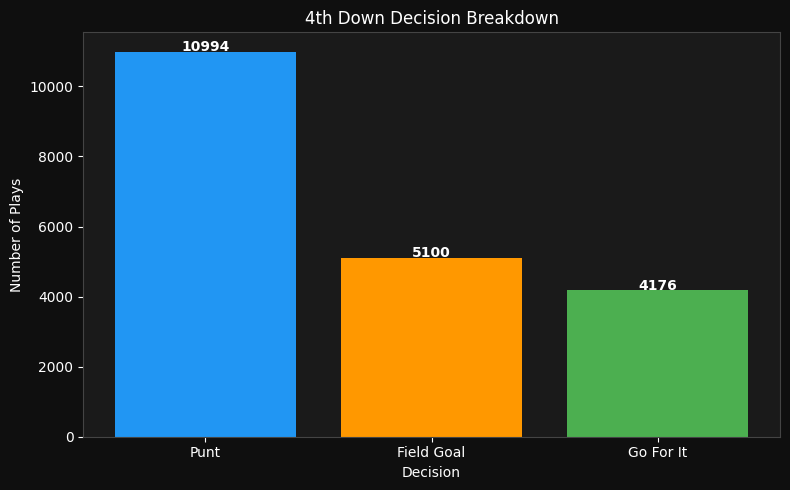

In [156]:
decision_counts = fourth_downs['decision'].value_counts()

plt.figure(figsize=(8,5))
plt.bar(decision_counts.index, decision_counts.values, color=['#2196F3', '#FF9800', '#4CAF50'])
plt.title('4th Down Decision Breakdown')
plt.xlabel('Decision')
plt.ylabel('Number of Plays')

for i, val in enumerate(decision_counts.values):
    plt.text(i, val +20, str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

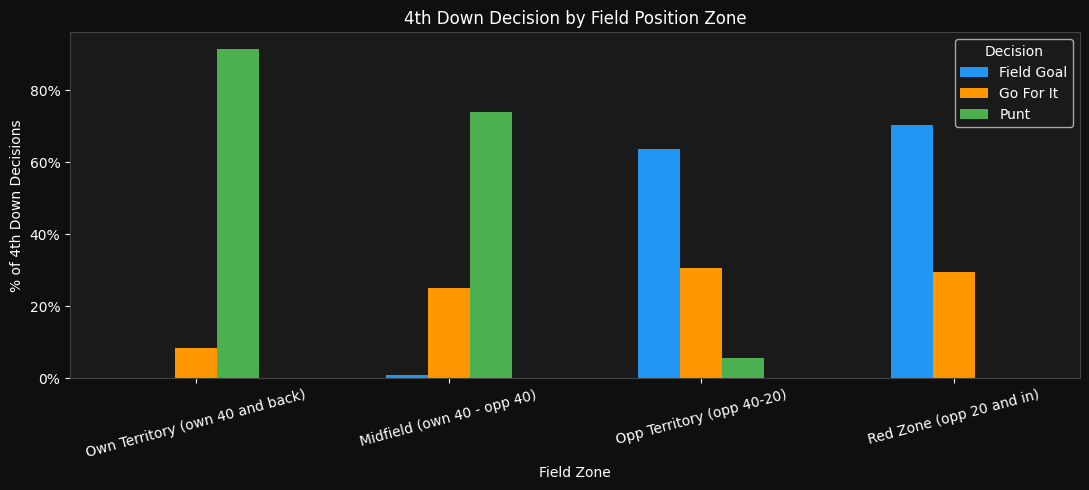

In [157]:
zone_order = [
    'Own Territory (own 40 and back)',
    'Midfield (own 40 - opp 40)', 
    'Opp Territory (opp 40-20)',
    'Red Zone (opp 20 and in)' 
]

zone_pct = zone_counts.div(zone_counts.sum(axis=1), axis=0) * 100
zone_pct = zone_pct.reindex(zone_order)

zone_pct.plot(kind = 'bar', figsize=(11,5), color = ['#2196F3', '#FF9800', '#4CAF50'])
plt.title('4th Down Decision by Field Position Zone')
plt.xlabel('Field Zone')
plt.ylabel('% of 4th Down Decisions')
plt.xticks(rotation=15)
plt.legend(title ='Decision')
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout()
plt.show()

## Phase 3: Conversion & Field Goal Probability Models

### 1. 4th Down Conversion Rate When Attempted

In [158]:
went_for_it = fourth_downs[fourth_downs['decision']=='Go For It'].copy()

print(f"\nTotal plays where team went for it: {len(went_for_it)}")
print(f"Overall conversion rate: {went_for_it['fourth_down_converted'].mean():.1f}")
print(f"\nConversions: {went_for_it['fourth_down_converted'].sum()}")
print(f"Failures: {went_for_it['fourth_down_failed'].sum()}")


Total plays where team went for it: 4176
Overall conversion rate: 0.5

Conversions: 2250.0
Failures: 1924.0


In [159]:
conv_by_ytg = (
    went_for_it.groupby('ydstogo')
    .agg( #mean and count at once
        conv_rate=('fourth_down_converted','mean'),
        n=('fourth_down_converted', 'count')
    )
    .reset_index()
)

conv_by_ytg[conv_by_ytg['n'] >= 10].head()

,ydstogo,conv_rate,n
0,1.0,0.682530,1660
1,2.0,0.582278,632
2,3.0,0.501205,415
3,4.0,0.517915,307
4,5.0,0.504167,240


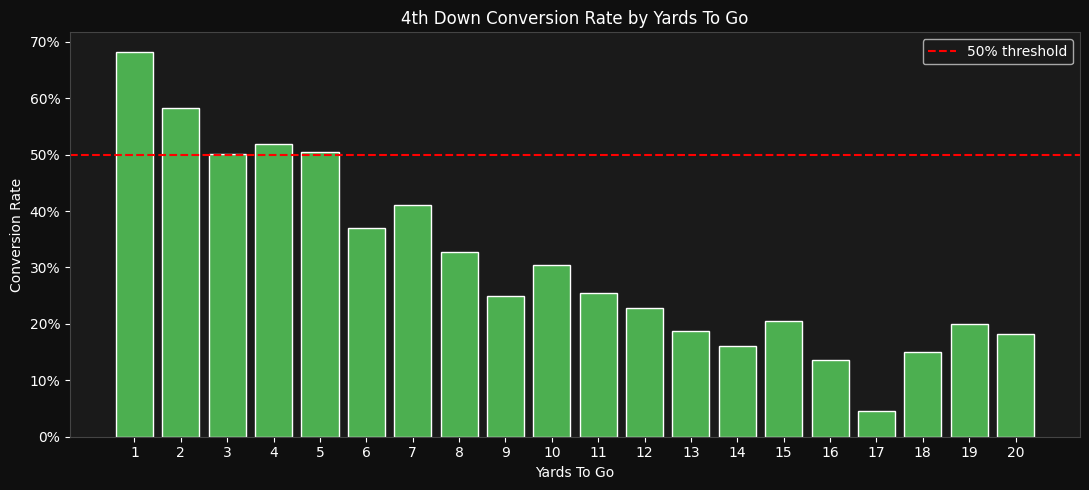

In [160]:
filtered = conv_by_ytg[conv_by_ytg['n'] >= 10]

plt.figure(figsize=(11,5))
plt.bar(filtered['ydstogo'], filtered['conv_rate']*100, color= "#4CAF50", edgecolor="white")
plt.axhline(50, color='red', linestyle='--', linewidth=1.5, label='50% threshold')
plt.title('4th Down Conversion Rate by Yards To Go')
plt.xlabel('Yards To Go')
plt.ylabel('Conversion Rate')
plt.xticks(filtered['ydstogo'])
plt.legend()
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout()
plt.show()

### 2. Logistic Regression Model For 4th Down Conversions

In [161]:
features = [
    'ydstogo',
    'yardline_100', 
    'score_differential',
    'game_seconds_remaining'
]

# ydstogo -- shorter = easier
# yardline_100 -- defenses play differently in different field positions
# score_differential -- affects how both teams play call
# game_seconds_remaining -- desperation late in games changes dynamic

model_data = went_for_it[features + ['fourth_down_converted']].dropna()

x = model_data[features]
y = model_data['fourth_down_converted']

print(f"Training samples: {len(x)}")
print(f"Features: {features}")

Training samples: 4176
Features: ['ydstogo', 'yardline_100', 'score_differential', 'game_seconds_remaining']


In [162]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42) #splits data 80-20 train test, 20 will be used to evaluate accuracy of model #random_state = 42 just sets a seed so we get same split every time

scaler = StandardScaler() #scales all features to the same range -- LogisticRegression is sensitive to features being on different scales, i.e. ydstogo is 1-20 but game_seconds_remaining 0-3600
x_train_scaled = scaler.fit_transform(x_train) #fit -- learns the stats of data, i.e. mean & sd of each column, 
x_test_scaled = scaler.transform(x_test) #transform -- uses stats (mean & sd) to scale the data

# For StandardScaler, scaled_value = (original - mean) / standard_deviation

model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(x_train_scaled, y_train)

print("Model trained!")

y_pred = model.predict(x_test_scaled) #runs test data through model, hard prediction for each play: 1=converts, 0=fails
y_prob = model.predict_proba(x_test_scaled)[: ,1] #runs test data through model, returns likelihood of converting. [: ,1] grads second column: converts column

print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.1%}") #compares models hard predictions against acutal outcomes
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.3}") #measures how well model ranks outcomes-- ROC of 1 is prefect, 0.5 is random guessing in this case

Model trained!

Accuracy: 62.6%
ROC-AUC: 0.67


### 3. Field Goal Make Probability by Distance

In [163]:
fg_plays = pbp[
    (pbp['play_type'] =='field_goal') &
    (pbp['field_goal_result'].isin(['made', 'missed']))
].copy()

fg_plays['made'] = (fg_plays['field_goal_result'] == 'made').astype(int)

print(f"Total field goal attempts: {len(fg_plays)}")
print(f"Overall make rate: {fg_plays['made'].mean():.1%}")

Total field goal attempts: 5488
Overall make rate: 86.9%


In [164]:
fg_plays['dist_bin'] = (fg_plays['kick_distance'] // 5) * 5 #// is floor divisor, so, rounding each distance to the nearest 5 yd bin.

fg_by_dist = (
    fg_plays.groupby('dist_bin')
    .agg(
        make_rate=('made', 'mean'),
        n=('made', 'count')
    )
    .reset_index()
    .query('n >= 10')
)

fg_by_dist

,dist_bin,make_rate,n
0,15.0,1.000000,12
1,20.0,0.996032,504
2,25.0,0.976157,713
3,30.0,0.976347,761
4,35.0,0.926923,780
5,40.0,0.847348,773
6,45.0,0.787037,756
7,50.0,0.758003,781
8,55.0,0.643478,345
9,60.0,0.520833,48


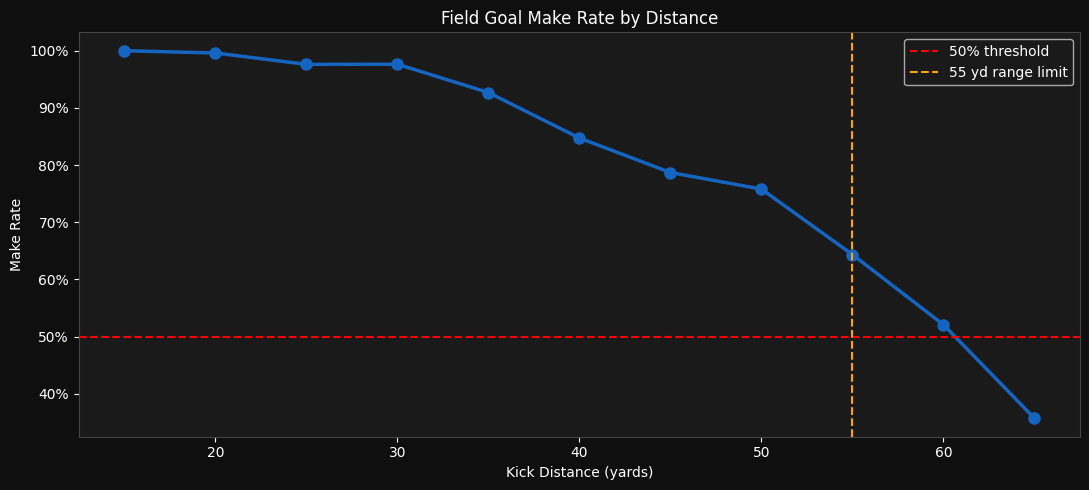

In [165]:
plt.figure(figsize=(11,5))
plt.plot(fg_by_dist['dist_bin'], fg_by_dist['make_rate']*100,
        'o-', color='#1565C0', linewidth=2.5, markersize=8)
plt.axhline(50, color = 'red', linestyle='--', linewidth=1.5, label='50% threshold')
plt.axvline(55, color = 'orange', linestyle='--', linewidth=1.5, label='55 yd range limit')
plt.title('Field Goal Make Rate by Distance')
plt.xlabel('Kick Distance (yards)')
plt.ylabel('Make Rate')
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter())
plt.legend()

plt.tight_layout()
plt.show()


## Phase 4: 4th Down Decision Framework

Decision framework logic:

For any 4th down situation, we're going to calculate the Expected Win Probability (EWP) for all three options and recommend whichever is highest: 

EWP(go) = P(convert) x WP_if_success + (1-P(convert)) x WP_if_failure
EWP(field_goal) = P(make) x WP_if_made + (1-P(make)) x WP_if_miss
EWP(punt) = WP_after_punt

P(convert) we already have from our logistic regression
P(make) we have from fg_by_dist table
We get WP from the historical averages in the play_by_play data

In [173]:
#1. WP after going for it (success v. failure)
went_for_it['wp_after'] = went_for_it['wp'] + went_for_it['wpa']

conv_wp_table = (
    went_for_it.groupby(['ydstogo', 'fourth_down_converted'])
    ['wp_after'].mean().reset_index()
    .rename(columns={'wp_after': 'avg_wp_after'})
)

#2. WP after punt by field position
punts = fourth_downs[fourth_downs['decision']=='Punt'].copy()
punts['wp_after'] = punts['wp'] + punts['wpa']
punts['yardline_bin'] = (punts['yardline_100']//10) * 10

punt_wp_table = (
    punts.groupby('yardline_bin')
    ['wp_after'].mean().reset_index()
    .rename(columns={'wp_after': 'avg_wp_after_punt'})
)

#3. WP after field goal (made v. missed)
fgs = fourth_downs[fourth_downs['decision'] == 'Field Goal'].copy()
fgs['wp_after'] = fgs['wp'] + fgs['wpa'] 
fgs['made'] = (fgs['field_goal_result'] == 'made').astype(int)
fgs['dist_bin'] = (fgs['kick_distance'] // 5) * 5

fg_wp_table = (
    fgs.groupby(['dist_bin', 'made'])
    ['wp_after'].mean().reset_index()
    .rename(columns={'wp_after': 'avg_wp_after_fg'})
)

print("Lookup tables built!")
print(f"\nConvert WP table: {len(conv_wp_table)} entries")
print(f"Punt WP table: {len(punt_wp_table)} entries")
print(f"Field Goal WP table: {len(fg_wp_table)} entries")

Lookup tables built!

Convert WP table: 53 entries
Punt WP table: 8 entries
Field Goal WP table: 21 entries


In [187]:
def recommend_4th_down(ydstogo, yardline_100, score_differential, game_seconds_remaining):
    #1. Predict conversion probability
    situation = pd.DataFrame([{
        'ydstogo': ydstogo,
        'yardline_100': yardline_100,
        'score_differential': score_differential,
        'game_seconds_remaining': game_seconds_remaining
    }])
    p_convert = model.predict_proba(scaler.transform(situation[features]))[0][1]

    #2. Expected WP: Go for it
    ytg = min(int(ydstogo), 10)
    wp_success = conv_wp_table.loc[
        (conv_wp_table['ydstogo'] == ytg) &
        (conv_wp_table['fourth_down_converted'] == 1), 'avg_wp_after'].values
    wp_failure = conv_wp_table.loc[
        (conv_wp_table['ydstogo'] == ytg) &
        (conv_wp_table['fourth_down_converted'] == 0), 'avg_wp_after'].values
    wp_success = wp_success[0] if len(wp_success) > 0 else 0.65
    wp_failure = wp_failure[0] if len(wp_failure) > 0 else 0.35

    ewp_go = p_convert * wp_success + (1-p_convert) * wp_failure

    #3. Expected WP: Punt
    yl_bin = (yardline_100 // 10) * 10
    wp_punt = punt_wp_table.loc[
        punt_wp_table['yardline_bin'] == yl_bin, 'avg_wp_after_punt'].values
    
    ewp_punt = wp_punt[0] if len(wp_punt) > 0 else 0.45

    #4. Expected WP: Field Goal
    fg_dist = yardline_100 + 17
    dist_bin = (fg_dist // 5) * 5
    p_make = fg_by_dist.loc[fg_by_dist['dist_bin'] == dist_bin, 'make_rate'].values
    p_make = p_make[0] if len(p_make) > 0 else max(0.1, 1-fg_dist / 70)

    wp_made = fg_wp_table.loc[
        (fg_wp_table['dist_bin'] == dist_bin) & 
        (fg_wp_table['made'] == 1), 'avg_wp_after_fg'].values
    wp_missed = fg_wp_table.loc[
        (fg_wp_table['dist_bin'] == dist_bin) & 
        (fg_wp_table['made'] == 0), 'avg_wp_after_fg'].values
    wp_made = wp_made[0] if len(wp_made) > 0 else 0.60
    wp_missed = wp_missed[0] if len(wp_missed) > 0 else 0.38

    ewp_fg = p_make * wp_made + (1-p_make) * wp_missed

    #5. Recommend Best Option
    options = {'Go For It': ewp_go,'Punt': ewp_punt, 'Field Goal': ewp_fg}
    best = max(options, key = options.get)

    field_pos = f"opp {yardline_100}" if yardline_100 <= 50 else f"own{100 - yardline_100}"

    print(f"4th & {ydstogo} | Yardline: {field_pos} | Score: {score_differential:+d} | {game_seconds_remaining //60} mins left")
    print(f" Conversion probability: {p_convert:.1%}")
    print(f" Go For it: EWP = {ewp_go:.3f}")
    print(f" Punt: EWP = {ewp_punt:.3f}")
    print(f" Field Goal: EWP = {ewp_fg:.3f}")

    print(f"\n Recommendation: {best}")

    #return options


### Testing the function:

In [188]:
#Scenario 1: Short yardage, opponent territory, tied game
recommend_4th_down(
    ydstogo = 1, 
    yardline_100 = 35, 
    score_differential = 0, 
    game_seconds_remaining = 1200
)

4th & 1 | Yardline: opp 35 | Score: +0 | 20 mins left
 Conversion probability: 66.1%
 Go For it: EWP = 0.476
 Punt: EWP = 0.617
 Field Goal: EWP = 0.544

 Recommendation: Punt


In [ ]:
#Scenario 2: long yardage, own terrority, losing late
recommend_4th_down(
    ydstogo = 8, 
    yardline_100=60,
    score_differential = -7,
    game_seconds_remaining = 120
)

4th & 8 | Yardline: own40 | Score: -7 | 2 mins left
 Conversion probability: 37.0%
 Go For it: EWP = 0.165
 Punt: EWP = 0.469
 Field Goal: EWP = 0.402

 Recommendation: Punt


In [206]:
#Scenario 3: Medium yardage, right on the edge of field goal range
recommend_4th_down(
    ydstogo=4, 
    yardline_100=20, 
    score_differential=-7, 
    game_seconds_remaining = 60
)

4th & 4 | Yardline: opp 20 | Score: -7 | 1 mins left
 Conversion probability: 50.6%
 Go For it: EWP = 0.305
 Punt: EWP = 0.940
 Field Goal: EWP = 0.586

 Recommendation: Punt


In [207]:
# Check what WP values the lookup tables are returning for this situation
yl_bin = round(20 / 10) * 10
print("Punt WP lookup:")
print(punt_wp_table[punt_wp_table['yardline_bin'] == yl_bin])

print("\nConversion WP lookup:")
print(conv_wp_table[conv_wp_table['ydstogo'] == 4])

print("\nFG WP lookup:")
fg_dist = 20 + 17
dist_bin = round(fg_dist / 5) * 5
print(fg_wp_table[fg_wp_table['dist_bin'] == dist_bin])

Punt WP lookup:
   yardline_bin  avg_wp_after_punt
0          20.0           0.939928

Conversion WP lookup:
   ydstogo  fourth_down_converted  avg_wp_after
6      4.0                    0.0      0.265029
7      4.0                    1.0      0.344308

FG WP lookup:
   dist_bin  made  avg_wp_after_fg
7      35.0     0         0.512913
8      35.0     1         0.592193
